# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Ricerra, Myke Lawrence
- _Student No._: 2024-07203
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1

![Interference wave](./figures/interference.png)

The figure illustrates a 2D wave interference pattern created by two sources specifically at coordinates (-1,0) and (1,0). The relation is governed by, $$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$

### Problem 2 

For larger matrices, using the (NumPy) @ operator is much preferred. According to multiple sources, NumPy works faster in larger data sets since it avoids the (slow) Python loops. On the other hand, for smaller matrices, I would still use the @ operator (or maybe hardcode the process since it only involves simple operations). Creating a custom matrix_multiply() function seems impractical when there already exists a much simpler operator that achieves the same result with minimal effort. 

Writing idiomatic Python made solving this problem significantly easier. It feels comparable to simply stating what you want the code to do. It is also less strict than other languages. Python automatically assigns data types to variables, reducing the amount of syntax you need to remember and type just to accomplish simple tasks. For all of the subparts of the second problem, these built-in features of Python allowed me to write clean and concise code without too much confusion (other than me mixing up the rows and columns of a matrix).

### Other comments
- Always remember to add inline notes or comments to remember what are the functions do, what the variables represent, which are the rows or columns of the matrix, etc.
- Name variables intuitively.

---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

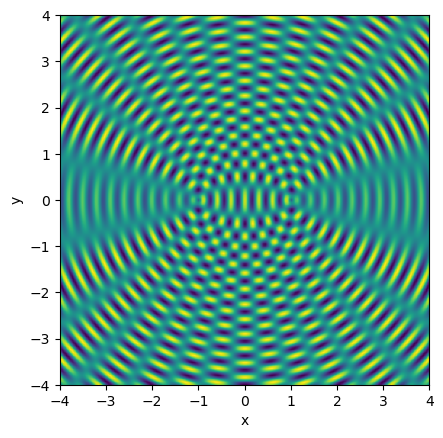

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math as mt

A = 1
k = 2/0.3*np.pi
part = [(-1,0),(1,0)]                                   # where the particles are

def interference(xs, ys):
    n = len(xs)
    Wr = [[0. for i in range(n)] for j in range(n)]     # creates a null matrix which will correspond to the scalar field
    for j, x in enumerate(xs):
        for i, y in enumerate(ys):
            for xpos, ypos in part:
                r = mt.sqrt((x-xpos)**2 + (y-ypos)**2)
                Wr[i][j] += A*np.sin(k*r)               # assigns value to each element of matrix which corresponds to value given by the equation
    return Wr

def plotfield(boxl, n):
    xs = [-boxl + l*2*boxl/(n-1) for l in range(n)]
    ys = xs[:]
    Wr = interference(xs, ys)
    xs = np.array(xs); ys = np.array(ys)
    Wr = np.array(Wr)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.imshow(Wr, extent=[-boxl, boxl, -boxl, boxl])
    
fig = plotfield(4, 255)

#### Problem 1 code summary

The code has two main parts, the equation and plotting. The first one outputs the values of the field (in matrix form) based on the sources of inteference which is then processed by the second function as a graph. The output is the plot.

---

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [2]:
import random as rn
number = rn.randint(1, 9)
number

1

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [3]:
def random_integer_matrix(nrows,ncols):
    mat = [[0 for j in range(ncols)] for i in range(nrows)] # creates a null i x j matrix based from nrows and ncols
    for l in range(ncols):                                  # call cols
        for k in range(nrows):                              # call rows
            mat[k][l] = rn.randint(1,9)                     # gives a random value for the kl^th element
                                                            # NOTE: mat[row_index][col_index]
    return mat

random_integer_matrix(3, 4)                                 # call the function to create a 3x4 matrix

[[3, 1, 4, 7], [5, 4, 9, 6], [5, 9, 2, 7]]

b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [4]:
def scalar_product(list1, list2):
    product = 0                          # define the product variable as 0
    if len(list1)==len(list2):
        for i in range(len(list1)):
            product += list1[i]*list2[i] # the products of list's elements with the same indices are summed to the product variable
    else: return print("INPUT VALID LISTS: Lists must have the same amount of elements.")
    return product

scalar_product([2,5],[1,3])              # the result should be 17

17

In [5]:
# use as many cell blocks as you want (as long as they all are functional)
# include valuable comments (even for trivial functions, a one-liner will do)

c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [6]:
def transpose_matrix(orig_matrix):
    trows = len(orig_matrix[0]) # the no. of rows of transpose is equal to the no. of columns of original
    tcols = len(orig_matrix) # vice versa of the above
    trans = [[0 for j in range(tcols)] for i in range(trows)] # makes a null i x j matrix
    for l in range(tcols): # call cols
        for k in range(trows): # call rows
            trans[k][l] = orig_matrix[l][k] # kl^th element of trans = lk^th element of orig
    return trans

# testing: the second resulting matrix should be the transpose of the first
x = random_integer_matrix(2,4)
print(x)
transpose_matrix(x)

[[1, 4, 8, 3], [9, 9, 5, 3]]


[[1, 9], [4, 9], [8, 5], [3, 3]]

d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [7]:
def matrix_multiply(left_matrix, right_matrix):
    lrows = len(left_matrix)
    lcols = len(left_matrix[0])                                     # no. of rows and columns of left matrix
    rrows = len(right_matrix)
    rcols = len(right_matrix[0])                                    # no. of rows and coloumns of right matrix
    if lcols == rrows:                                              # mat mult is only valid for (a x b)*(b x c) sized matrices
        product = [[0 for y in range(rcols)] for x in range(lrows)] # makes a null x by y matrix
        trmat = transpose_matrix(right_matrix)                      # since row x col, transpose right matrix to have 2 corresponding lists with same amount of elements
        for j in range(rcols):
            for i in range(lrows):
                product[i][j] += scalar_product(left_matrix[i], trmat[j]) # from previous comment, every element of left row is multiplied to corresponding transposed right column then summed, simply scalar product.
    else: return print("INPUT VALID MATRICES: Columns of left matrix should be equal to the rows of right matrix.")
    return product

# testing
lmat = random_integer_matrix(3,2)
rmat = random_integer_matrix(2,2)
print(lmat)
print(rmat)
matrix_multiply(lmat, rmat)

[[2, 5], [1, 6], [3, 6]]
[[6, 5], [8, 1]]


[[52, 15], [54, 11], [66, 21]]

#### Problem 2 code summary

The code is written so that the transpose and scalar product functions are utilized to find the result of matrix multiplication. Cases where the function inputs are invalid are also considered, hence why there are 'else' statements that display an error message.